In [2]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [3]:
df = pd.read_csv(r"C:\Users\adin\Downloads\Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
df.shape

(162980, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  str    
 1   category    162973 non-null  float64
dtypes: float64(1), str(1)
memory usage: 2.5 MB


In [5]:
df.describe()

,category
count,162973.000000
mean,0.225436
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [9]:
# Text Preprocessing

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text

df["clean_text"] = df["clean_text"].apply(clean_text)

df.head()

,clean_text,category
0,when modi promised minimum government maximum ...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [11]:
# Create Vocabulary

all_words = []

for sentence in df["clean_text"]:

    all_words.extend(sentence.split())

word_freq = Counter(all_words)

print("Total Words:", len(all_words))
print("Unique Words:", len(word_freq))

Total Words: 163091
Unique Words: 87


In [12]:
# Top Frequent Words

top_words = word_freq.most_common(10)

print(top_words)

[('nan', 162975), ('modi', 7), ('the', 6), ('and', 4), ('what', 4), ('should', 3), ('for', 3), ('state', 2), ('not', 2), ('all', 2)]


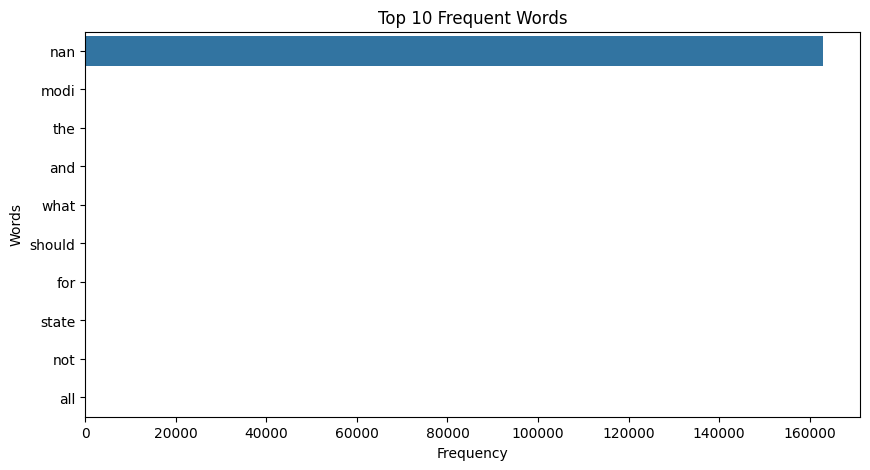

In [14]:
# Visualization

words = [x[0] for x in top_words]

counts = [x[1] for x in top_words]

plt.figure(figsize=(10,5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 10 Frequent Words")

plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [15]:
# Autocomplete Function

def autocomplete(prefix, vocabulary, n=5):

    suggestions = []

    for word in vocabulary:

        if word.startswith(prefix.lower()):

            suggestions.append(
                (word, vocabulary[word])
            )

    suggestions = sorted(
        suggestions,
        key=lambda x: x[1],
        reverse=True
    )

    return [word for word, freq in suggestions[:n]]

In [16]:
# Test Autocomplete
prefixes = [
    "da",
    "ma",
    "py",
    "an"
]

for p in prefixes:

    print("Prefix:", p)

    print(
        autocomplete(
            p,
            word_freq
        )
    )

    print()

Prefix: da
[]

Prefix: ma
['maximum', 'main', 'may']

Prefix: py
[]

Prefix: an
['and', 'answer']



In [17]:
# Autocorrect Function

def autocorrect(word):

    return str(
        TextBlob(word).correct()
    )

In [18]:
# Test Autocorrect

wrong_words = [

    "machne",

    "analytcs",

    "scince",

    "algorthm",

    "engneer"
]

for word in wrong_words:

    print(
        word,
        "->",
        autocorrect(word)
    )

machne -> machine
analytcs -> analysis
scince -> since
algorthm -> algorthm
engneer -> engineer


In [19]:
# Accuracy Calculation

test_words = {

    "machne": "machine",

    "analytcs": "analytics",

    "scince": "science",

    "algorthm": "algorithm",

    "engneer": "engineer"
}

correct = 0

for wrong, actual in test_words.items():

    prediction = autocorrect(wrong)

    if prediction == actual:

        correct += 1

accuracy = (
    correct /
    len(test_words)
) * 100

print(
    "Accuracy:",
    round(
        accuracy,
        2
    ),
    "%"
)


Accuracy: 40.0 %


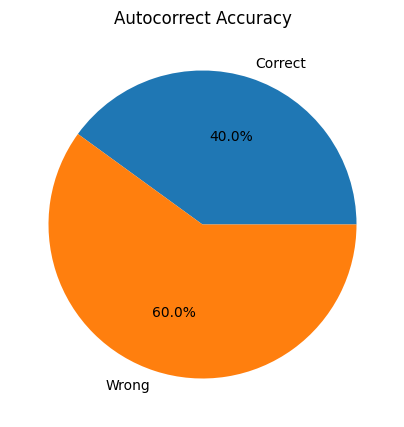

In [20]:
# Accuracy Pie Chart

plt.figure(figsize=(5,5))

plt.pie(
    [
        correct,
        len(test_words)-correct
    ],

    labels=[
        "Correct",
        "Wrong"
    ],

    autopct="%1.1f%%"
)

plt.title(
    "Autocorrect Accuracy"
)

plt.show()

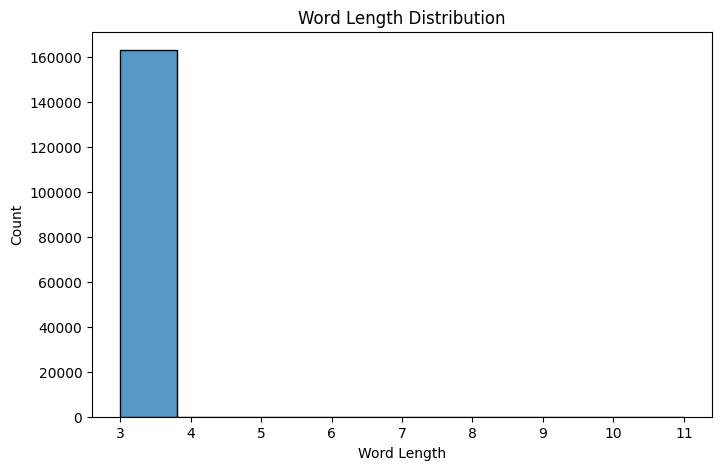

In [21]:
# Word Length Distribution

lengths = [

    len(word)

    for word in all_words
]

plt.figure(figsize=(8,5))

sns.histplot(
    lengths,
    bins=10
)

plt.title(
    "Word Length Distribution"
)

plt.xlabel("Word Length")
plt.ylabel("Count")

plt.show()

In [22]:
# project summary

print("PROJECT SUMMARY")
print("----------------")

print(
    "Total Words:",
    len(all_words)
)

print(
    "Unique Words:",
    len(word_freq)
)

print(
    "Autocomplete Working: YES"
)

print(
    "Autocorrect Accuracy:",
    round(
        accuracy,
        2
    ),
    "%"
)

PROJECT SUMMARY
----------------
Total Words: 163091
Unique Words: 87
Autocomplete Working: YES
Autocorrect Accuracy: 40.0 %
